In [26]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

import volprim
from volprim.integrators.common import *

from scripts.radiosity.radiance_cache import RadianceCache
from scripts.radiosity.radiance_cache import render_hemisphere_rt, render_hemisphere_rt_inverse, dir_to_sph
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
def seek(scene_path: str, gs_path: str, u_px: int, v_px: int):
    scene = mi.load_file(scene_path)
    rc = RadianceCache(scene, gs_path)
    u, v = u_px / 683, v_px / 512
    ray = scene.sensors()[0].sample_ray(0.0, 0.0, mi.Point2f(u,v), dr.zeros(mi.Point2f))[0]
    si = scene.ray_intersect(ray)
    plt.figure()
    plt.imshow(mi.render(rc.mi_scene))
    plt.scatter(u_px, v_px, s=80, linewidths=1.5, c='limegreen', marker='o', edgecolor='k')
    print(si.bsdf().eval_diffuse_reflectance(si))

In [105]:
GAMMA_CORRECT = True

def get_si(scene_path: str, u_px: int, v_px: int):
    scene = mi.load_file(scene_path)
    u, v = u_px / 683, v_px / 512
    ray = scene.sensors()[0].sample_ray(0.0, 0.0, mi.Point2f(u,v), dr.zeros(mi.Point2f))[0]
    si = scene.ray_intersect(ray)
    return si, scene

def plot_Lo(si: mi.SurfaceInteraction3f, scene1: mi.Scene, scene2: mi.Scene, filename="Lo_comparison"):
    sampler = mi.load_dict({'type': 'independent'})

    N = 256
    img1 = render_hemisphere_rt_inverse(scene1, si, sampler, N, spp = 256)[0]
    img2 = render_hemisphere_rt_inverse(scene2, si, sampler, N, spp = 256)[0]
    mi.util.write_bitmap("Lo_GS.exr", mi.Bitmap(img1))
    mi.util.write_bitmap("Lo_RT.exr", mi.Bitmap(img2))

    if GAMMA_CORRECT:
        img1 **= (1/2.2)
        img2 **= (1/2.2)

    fig = plt.figure(figsize=(10,6), dpi=200)
    gs = fig.add_gridspec(2,2)
    ax2 = fig.add_subplot(gs[0, 0])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[0, 1])
    ax5 = fig.add_subplot(gs[1, 1])

    # img1 = img1.numpy()
    # img1[:, 2*N:,:] = img1[:, :2*N,:]

    # img2 = img2.numpy()
    # img2[:, 2*N:,:] = img2[:, :2*N,:]
    img1 = img1[:,:2*N,:]
    img2 = img2[:,:2*N,:]

    ax2.imshow(img1, extent=[0, dr.pi, 0.5 * dr.pi, 0.0])
    ax2.set_yticks([0.0, dr.pi/2]); ax2.set_ylabel(r"$\theta$")
    ax2.set_yticklabels([r"0.0", r"0.5$\pi$"])
    ax2.set_xticks([0.0, dr.pi/2, dr.pi]); ax2.set_xticklabels(""); ax2.set_xlabel("")
    ax2.set_title(r"$L_{o}(\omega)$, $\alpha$ = 0.9")

    ax3.imshow(img2, extent=[0, dr.pi, 0.5 * dr.pi, 0.0])
    ax3.set_xticks([0.0, dr.pi/2, dr.pi]); ax3.set_xlabel(r"$\varphi$")
    ax3.set_xticklabels([r"0.0", r"0.5$\pi$", r"$\pi$"])
    ax3.set_yticks([0.0, dr.pi/2]); ax3.set_ylabel(r"$\theta$")
    ax3.set_yticklabels([r"0.0", r"0.5$\pi$"])
    ax3.set_title(r"$L_{o}(\omega)$, $\alpha$ = 0.5")


    sampler.seed(0, 1 << 10)
    angles = dir_to_sph(mi.warp.square_to_cosine_hemisphere(sampler.next_2d()))
    theta, phi = angles.x, angles.y
    phi[phi > dr.pi] -= dr.pi
    ax4.imshow(img1, extent=[0, dr.pi, 0.5 * dr.pi, 0.0])
    ax4.set_yticks([0.0, dr.pi/2]);
    ax4.set_yticklabels([])
    ax4.set_xticks([0.0, dr.pi/2, dr.pi]); ax4.set_xticklabels(""); ax4.set_xlabel("")
    ax4.scatter(phi, theta, c='k', s=0.5, label="Cosine sampling")
    ax4.vlines(dr.pi, 0.0, dr.pi/2, 'k')
    ax4.legend(loc=4)

    angles = dir_to_sph(mi.warp.square_to_uniform_hemisphere(sampler.next_2d()))
    theta, phi = angles.x, angles.y
    phi[phi > dr.pi] -= dr.pi
    ax5.imshow(img2, extent=[0, dr.pi, 0.5 * dr.pi, 0.0])
    ax5.set_xticks([0.0, dr.pi/2, dr.pi]); ax5.set_xlabel(r"$\varphi$")
    ax5.set_xticklabels([r"0.0", r"0.5$\pi$", r"$\pi$"])
    ax5.set_yticks([0.0, dr.pi/2]);
    ax5.set_yticklabels([])
    ax5.scatter(phi, theta, c='k', s=0.5, label="Uniform sampling")
    ax5.vlines(dr.pi, 0.0, dr.pi/2, 'k')
    ax5.legend(loc=4)

    plt.tight_layout()
    plt.savefig(f"{filename}.png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0797122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0797122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0797122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0797122].


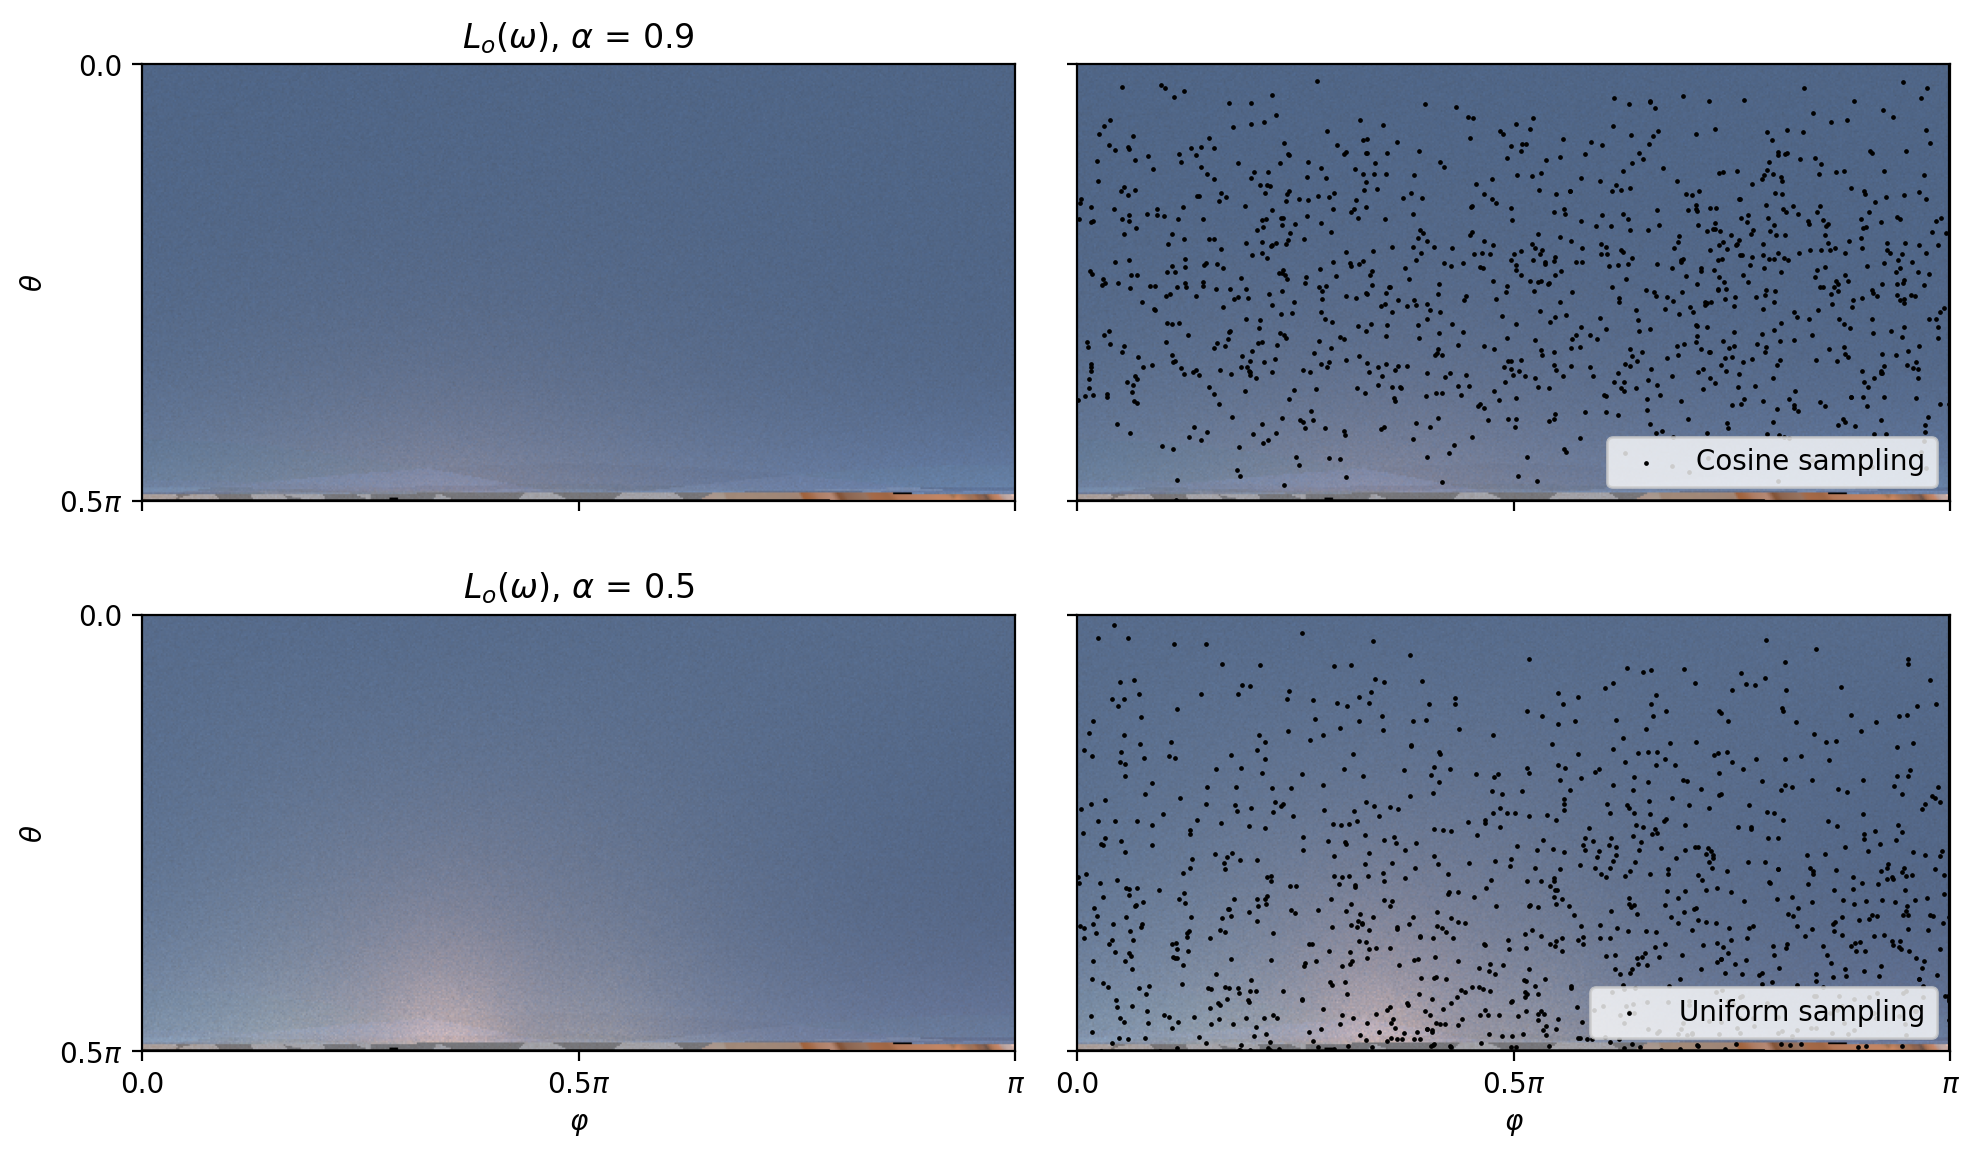

In [ ]:
scene1fp = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_museum_texwave_l1/matpreview_diff1.xml"
scene2fp = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_museum_texwave_l1/matpreview_diff2.xml"
u_px, v_px = 263, 101

si, scene1 = get_si(scene1fp, u_px, v_px)
_,  scene2 = get_si(scene2fp, u_px, v_px)
# seek(scene_path, gs_path, u_px, v_px)
plot_Lo(si, scene1, scene2, "wo_sampling")